# Importing the dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from dataHandler import * 


In [2]:
df = pd.read_csv('data/horseData.csv')
df = clean_data(df)
df.head(10)

Shape of dataset: (65150, 24)


/var/folders/m6/wqgw_v5x3tq4t4q1zm2fc5f80000gn/T/ipykernel_2286/3051193955.py:1: DtypeWarning: Columns (0: price, 1: purchaser) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/horseData.csv')


,name,form,rating,rawErg,erg,age,sex,sire,fee,crop,dam,ems3,bmSire,damForm
1,Aussie Pride,2,86,80,71,8,G,Curlin,150000.0,9,Bounding,57,Lonhro,4
3,Mendelssohn,4,101,73,73,11,C,Scat Daddy,30000.0,7,Leslie's Lady,56,Tricky Creek,0
5,Brother in Arms,1,79,90,91,8,G,War Front,250000.0,11,Believe You Can,57,Proud Citizen,4
7,Gun It,2,97,150,150,10,C,Tapit,300000.0,11,Miss Besilu,79,Medaglia d'Oro,3
8,Declarationofpeace,0,85,127,118,11,C,War Front,150000.0,8,Serena's Cat,67,Storm Cat,0
9,Miss Besilu,3,83,82,0,15,F,Medaglia d'Oro,100000.0,6,Quiet Dance,65,Quiet American,2
11,Tatweej,2,103,83,74,10,C,Tapit,300000.0,11,Tiz Miz Sue,55,Tiznow,4
12,Lidstrom,2,76,93,83,8,G,Tapit,300000.0,13,Seeking Gabrielle,58,Forestry,2
13,Metro,0,58,77,67,5,C,Quality Road,200000.0,10,True Feelings,56,Latent Heat,2
15,Conquistador,2,83,53,60,11,G,Tiznow,20000.0,13,Moonbow,49,Distorted Humor,0


# Clustering data


## Standardizing the data:

In [3]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Droppping names and other non-numeric columns for clustering
target = df['rating']
df = df.drop(columns=['name', 'bmSire', 'dam', 'sire', 'sex', 'rating'])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, columns=df.columns, index=df.index)

scaled_df.head()


,form,rawErg,erg,age,fee,crop,ems3,damForm
1,0.463280,2.318911,1.839478,-0.592763,3.234033,0.696944,1.603220,2.506636
3,2.936648,1.927178,1.928093,0.372220,-0.044909,0.267969,1.495731,-1.187646
5,-0.773404,2.878529,2.725631,-0.592763,5.966484,1.125918,1.603220,2.506636
7,0.463280,6.236237,5.339781,0.050559,7.332709,1.125918,3.967971,1.583066
8,-2.010088,4.949116,3.921937,0.372220,3.234033,0.482457,2.678107,-1.187646


## Using the elbow method to find the optimum k 

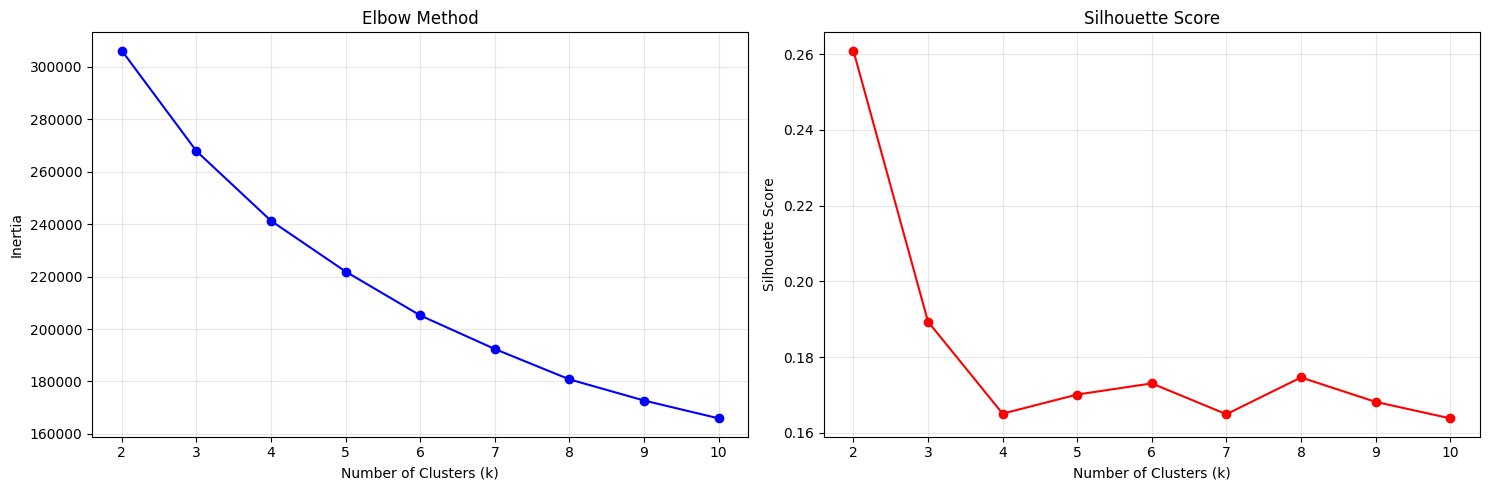

In [4]:
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertias.append(kmeans.inertia_)
    
    labels = kmeans.labels_
    score = silhouette_score(scaled_data, labels)
    silhouette_scores.append(score)

# Plot both metrics
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Performing last k-means and graphing the result via PCA


Clustering with k=2:
Cluster counts:
Cluster
0    35062
1    14912
Name: count, dtype: int64

Cluster Statistics:
             form     rawErg        erg        age           fee      crop  \
Cluster                                                                      
0        1.639096  30.157721  20.139211  10.213593  18873.460955  4.226171   
1        1.593146  58.324705  51.455874   8.971030  61669.320212  9.335099   

              ems3   damForm  
Cluster                       
0        38.515002  1.154041  
1        50.478205  1.596030  

PC1 loadings (how much each feature contributes):
rawErg     0.527901
ems3       0.458389
erg        0.454219
fee        0.411099
crop       0.296562
damForm    0.160465
form      -0.012622
age       -0.148408
dtype: float64

PC2 loadings:
age        0.799329
form       0.274926
crop       0.223570
ems3       0.214199
rawErg     0.202595
damForm    0.091232
fee        0.014588
erg       -0.374223
dtype: float64


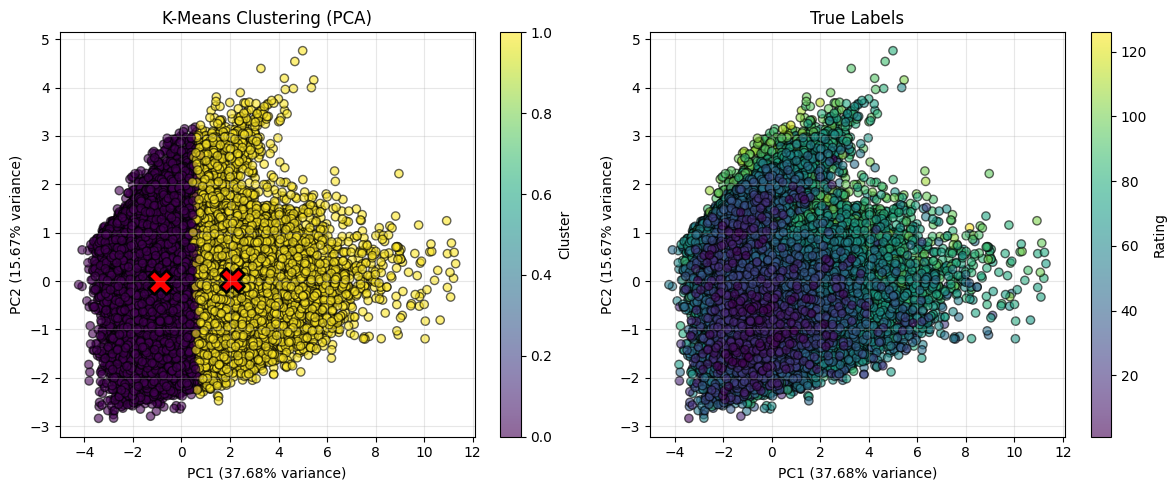

In [5]:
# Step 3: Perform final clustering with optimal k
from sklearn.decomposition import PCA


optimal_k = 2  # Based on the plots

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(scaled_data)
centroids = kmeans.cluster_centers_

# Add cluster labels to dataframe
df['Cluster'] = labels

print(f"\nClustering with k={optimal_k}:")
print(f"Cluster counts:\n{df['Cluster'].value_counts().sort_index()}")

# Step 4: Analyze clusters
print("\nCluster Statistics:")
cluster_stats = df.groupby('Cluster').mean()
print(cluster_stats)



# Step 5: Visualize with PCA (reduce to 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_data)

features = df.columns[:-1]  # Exclude 'Cluster' column

print("\nPC1 loadings (how much each feature contributes):")
pc1_loadings = pd.Series(pca.components_[0], index=features).sort_values(ascending=False)
print(pc1_loadings)

print("\nPC2 loadings:")
pc2_loadings = pd.Series(pca.components_[1], index=features).sort_values(ascending=False)
print(pc2_loadings)


plt.figure(figsize=(12, 5))

# Plot 1: Clusters
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.6, edgecolors='black')
centroids_pca = pca.transform(centroids)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=300, edgecolors='black', linewidths=2)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('K-Means Clustering (PCA)')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

# Plot 2: True labels (if available)
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=target, cmap='viridis', alpha=0.6, edgecolors='black')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('True Labels')
plt.colorbar(label='Rating')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()